In [2]:
library(limma)
library(Biobase)
library(dplyr)
library(ggplot2)
library(magrittr)
library(ggrepel)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.



Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following

Expression Set object

In [3]:
data <- read.csv("extdata/all_lmci_metab_hmdb_lilikoi.csv", header=TRUE)
name_map <- read.csv("extdata/name_map.csv",header=TRUE)

In [4]:
for (i in 1:nrow(name_map)){
    number=substr(name_map$HMDB[i], nchar(name_map$HMDB[i]) - 5 + 1, nchar(name_map$HMDB[i]))
    hmdb_name=paste("HMDB",number,sep="")
    name_map$HMDB[i]=hmdb_name
}
name_map

Query,Match,HMDB,PubChem,KEGG,SMILES,Comment
<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>
HMDB0013438,"PC(o-18:2(9Z,12Z)/24:0)",HMDB13438,53481741,NA,CCCCCCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COCCCCCCCC/C=C\C/C=C\CCCCC)COP(=O)([O-])OCC[N+](C)(C)C,1
HMDB0010169,SM(d18:1/16:0),HMDB10169,5283590,C00550,CCCCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCC[N+](C)(C)C)[C@@H](/C=C/CCCCCCCCCCCCC)O,1
HMDB0007887,PC(14:0/22:1(13Z)),HMDB07887,53478609,C00157,CCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCCCCCC/C=C\CCCCCCCC,1
HMDB0013449,"PC(o-22:0/22:3(10Z,13Z,16Z))",HMDB13449,53481753,NA,CCCCCCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCCC/C=C\C/C=C\C/C=C\CCCCC,1
HMDB0013458,"PC(o-24:0/18:3(6Z,9Z,12Z))",HMDB13458,53481771,NA,CCCCCCCCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCC/C=C\C/C=C\C/C=C\CCCCC,1
HMDB0013429,"PC(o-18:1(9Z)/18:2(9Z,12Z))",HMDB13429,6443159,NA,CCCCCCCC/C=C\CCCCCCCCOC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCC/C=C\C/C=C\CCCCC,1
HMDB0013412,PC(o-16:1(9Z)/18:0),HMDB13412,53481707,NA,CCCCCCCCCCCCCCCCCC(=O)O[C@H](COCCCCCCCC/C=C\CCCCCC)COP(=O)([O-])OCC[N+](C)(C)C,1
HMDB0013414,PC(o-16:1(9Z)/20:0),HMDB13414,53481711,NA,CCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COCCCCCCCC/C=C\CCCCCC)COP(=O)([O-])OCC[N+](C)(C)C,1
HMDB0011151,"PC(O-16:0/18:2(9Z,12Z))",HMDB11151,6443157,NA,CCCCCCCCCCCCCCCCOC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCC/C=C\C/C=C\CCCCC,1


In [5]:
data_1 = data[,c(-1,-2)]

In [6]:
rownames(data_1) = data$PID #rownames(data)

In [7]:
data_2 = t(data_1)

In [8]:
data_2

,002_S_0729,002_S_1155,002_S_1268,002_S_4171,002_S_4219,002_S_4229,002_S_4251,002_S_4521,002_S_4654,003_S_0908,⋯,141_S_0697,141_S_1004,141_S_1052,141_S_1255,141_S_4053,141_S_4426,141_S_4456,153_S_4077,941_S_4187,941_S_4377
HMDB00619,-0.59054563,2.18049949,2.79221794,1.29458105,-0.2122178,2.871248735,0.3530699,0.1955771,-0.62744941,0.541802531,⋯,-1.131575265,-0.08430584,1.14679526,-0.46087995,2.13410101,0.38333806,2.11277587,-0.48939910,0.212062012,0.07660435
HMDB00518,-1.41152196,1.49077378,2.95264319,0.72114016,-0.5241116,1.756966533,1.1704509,0.8177700,-0.80565330,0.416446016,⋯,-0.188183804,1.05347448,0.61355352,-0.83835551,1.98636644,0.82452623,1.79632691,-0.58829357,0.974114615,1.76098416
HMDB00626,-1.73253816,-0.62925692,2.17894160,-0.94262415,0.4868495,1.656648627,-3.0000000,1.3073933,0.31107068,0.080123518,⋯,-0.261547381,0.78940994,0.92055334,-0.20337712,1.60871067,0.23329054,0.82857534,0.43780101,-0.003871697,1.33628484
HMDB00138,-0.74757071,0.65778471,0.95433102,0.06860004,0.7653707,-0.393747986,-0.3152278,0.2660627,2.31459692,1.033248662,⋯,1.682960988,1.51237255,-0.01510469,0.31455981,0.14180328,1.59514214,-0.27029541,-1.33661086,-0.178750707,-0.59264982
HMDB02579,-0.74348754,-0.06307190,1.29779845,0.10060677,1.0684119,-0.484841231,0.7498075,0.9336354,1.41963020,0.993672336,⋯,1.257899984,1.40252990,0.34290036,-0.07077680,0.90560072,0.89268625,0.24689283,-1.09170334,0.029999824,0.60108263
HMDB00631,-1.01640878,-1.30881978,0.84684625,-0.95683232,1.4022726,-0.144359920,-3.0000000,0.9751291,2.15297451,0.929876759,⋯,1.446314766,1.36773193,0.63153019,-0.22742797,0.71508574,0.13825694,-0.13343950,-0.21883738,-0.333054568,0.33584582
HMDB00698,-0.08184015,-1.27852804,1.07769932,-0.06884868,0.7225712,-0.419055575,-1.2785280,0.9923747,-0.62735611,0.804890452,⋯,-0.317326986,0.65296810,0.99478741,-0.31732699,0.94747332,-1.27852804,-1.27852804,-0.35806153,-0.370609969,0.89941087
HMDB00708,-0.82211255,-0.09841241,1.04688924,-0.04718325,1.0579992,0.235678584,1.8980407,0.7260581,0.57924466,0.624916166,⋯,-0.747224873,0.69503711,-0.25638358,0.03838447,0.63427978,1.66130476,1.21651185,-2.18594630,0.479987166,1.48083755
HMDB00036,-0.60924508,0.92348220,-0.02818655,-0.08984399,0.8424823,-1.157859601,-1.1578596,0.0555832,2.92443353,1.125559690,⋯,2.065463196,1.39701012,-1.15785960,0.46153522,-0.65835907,1.72897628,-0.63197687,-1.15785960,-0.332009305,-0.55415631
HMDB00951,-0.35866655,0.65061992,-0.15633821,-0.34177871,0.8688591,-2.521425763,-0.1216612,0.6493929,2.56640039,1.330582014,⋯,1.746939216,1.34222438,-0.02067727,0.60613235,-0.45564947,1.14514151,0.20338311,-1.02264219,-0.307212157,-0.09211908


In [9]:
subtype_info<-read.csv("extdata/cn_emci_lmci_ad_clin_pseudotime.csv",header=TRUE)
table(subtype_info$SNF)
name_lmci1<-subtype_info$PID[which(subtype_info$SNF=="lmcisubtype1")]
name_lmci2<-subtype_info$PID[which(subtype_info$SNF=="lmcisubtype2")]


          AD           CN emcisubtype1 emcisubtype2 lmcisubtype1 lmcisubtype2 
         339          534          108           93           85          115 

In [10]:
# subset clusters for c=2 SNF MRNA + METAB

data_subset_1=as.matrix(data_2[,name_lmci1])
data_subset_2=as.matrix(data_2[,name_lmci2])
dim(data_subset_1)
dim(data_subset_2)

data_subset = cbind(data_subset_1,data_subset_2)

dataset <- ExpressionSet(assayData=as.matrix(data_subset))

sub1 = dim(data_subset_1)[2]
sub2 = dim(data_subset_2)[2]
design = cbind(c(c(rep(1, sub1)),c(rep(0, sub2))),c(c(rep(0, sub1)),c(rep(1, sub2))))
colnames(design) <- c("subset1","subset2")

[1] 172  85

[1] 172 115

In [11]:
fit <- lmFit(data_subset, design)
cont.matrix <- makeContrasts(contrasts = "subset2-subset1", levels=design) #subtype1 as control
fit2 <- contrasts.fit(fit, cont.matrix)
fit2 <- eBayes(fit2, trend=FALSE)
limma_result_fit <- topTable(fit2,  coef=1, n=Inf)
limma_result_fit$metab_symbol <- row.names(limma_result_fit)

In [12]:
limma_result_fit

,logFC,AveExpr,t,P.Value,adj.P.Val,B,metab_symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
HMDB13467,1.373014,-0.12348285,12.027827,6.208971e-27,1.067943e-24,50.46823,HMDB13467
HMDB13412,1.367350,-0.18155501,11.852431,2.458825e-26,2.114590e-24,49.11246,HMDB13412
HMDB13464,1.308971,-0.13850548,11.057698,1.158358e-23,6.641253e-22,43.05070,HMDB13464
HMDB13411,1.242196,-0.17931760,10.782282,9.442574e-23,4.060307e-21,40.98506,HMDB13411
HMDB13465,1.241412,-0.04773577,10.474231,9.635995e-22,3.314782e-20,38.69888,HMDB13465
HMDB13462,1.252734,-0.14139616,10.250237,5.129110e-21,1.430846e-19,37.05373,HMDB13462
HMDB13405,1.180750,-0.14275749,10.233151,5.823209e-21,1.430846e-19,36.92887,HMDB13405
HMDB00564,1.237032,-0.19119384,10.200978,7.393598e-21,1.589624e-19,36.69398,HMDB00564
HMDB01348,1.308935,-0.15607662,10.184513,8.353462e-21,1.596439e-19,36.57390,HMDB01348


In [13]:
#### plot volcano
fold_cutoff = 0.3
limma_result_fit$diffexpressed <- "NO"
# if log2Foldchange > 0.5 and pvalue < 0.05, set as "UP" 
limma_result_fit$diffexpressed[limma_result_fit$logFC > fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "UP"
# if log2Foldchange < -0.5 and pvalue < 0.05, set as "DOWN"
limma_result_fit$diffexpressed[limma_result_fit$logFC < -fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "DOWN"

limma_result_fit$delabel <- NA

for (i in 1:nrow(limma_result_fit)){
    if (limma_result_fit$diffexpressed[i] != "NO"){
        hmdb_name=limma_result_fit$metab_symbol[i]
        if (hmdb_name %in% name_map$HMDB){
            idx=which(name_map$HMDB==hmdb_name)
            real_name=name_map$Match[idx]
            limma_result_fit$delabel[i]=real_name
        }
    }
}


Warning message:
“Removed 89 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 78 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 89 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 78 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


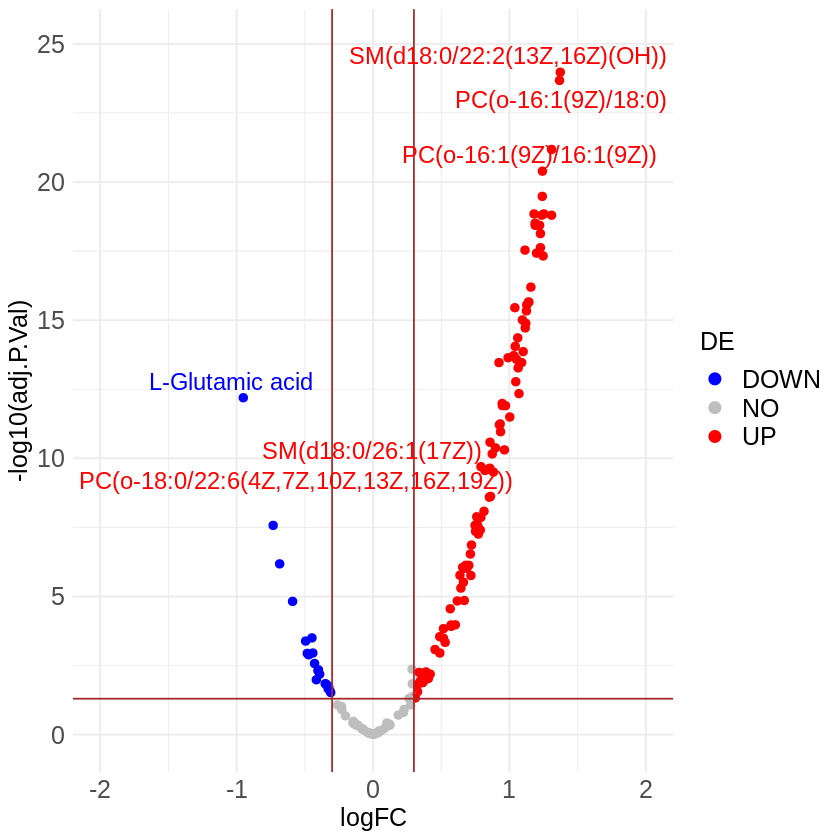

In [14]:
ggplot(data=limma_result_fit, aes(x=logFC, y=-log10(adj.P.Val),col=diffexpressed)) +
        geom_point(size=2) +
        theme_minimal() +
        scale_color_manual(breaks=c("DOWN","NO","UP"),values=c("blue", "grey", "red")) +
        guides(color=guide_legend(title = "DE",override.aes = list(size = 3))) +
        geom_vline(xintercept=c(-fold_cutoff, fold_cutoff), col="brown") +
        geom_hline(yintercept=-log10(0.05), col="brown") + 
        xlim(-2, 2) +ylim(-0.1,25) +
        theme(axis.title = element_text(size = 15),axis.text=element_text(size=15),legend.title=element_text(size=15),legend.text=element_text(size=15))+
        geom_text_repel(aes(label=delabel),size=5,max.overlaps=5,force=10)

ggsave("figs/RP_2h.png",dpi=600) 

In [15]:
limma_DE = limma_result_fit[which(limma_result_fit$diffexpressed != "NO"), ]

In [16]:
limma_DE

,logFC,AveExpr,t,P.Value,adj.P.Val,B,metab_symbol,diffexpressed,delabel
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
HMDB13467,1.373014,-0.12348285,12.027827,6.208971e-27,1.067943e-24,50.46823,HMDB13467,UP,"SM(d18:0/22:2(13Z,16Z)(OH))"
HMDB13412,1.367350,-0.18155501,11.852431,2.458825e-26,2.114590e-24,49.11246,HMDB13412,UP,PC(o-16:1(9Z)/18:0)
HMDB13464,1.308971,-0.13850548,11.057698,1.158358e-23,6.641253e-22,43.05070,HMDB13464,UP,NA
HMDB13411,1.242196,-0.17931760,10.782282,9.442574e-23,4.060307e-21,40.98506,HMDB13411,UP,PC(o-16:1(9Z)/16:1(9Z))
HMDB13465,1.241412,-0.04773577,10.474231,9.635995e-22,3.314782e-20,38.69888,HMDB13465,UP,"SM(d18:0/20:2(11Z,14Z))"
HMDB13462,1.252734,-0.14139616,10.250237,5.129110e-21,1.430846e-19,37.05373,HMDB13462,UP,SM(d18:0/14:1(9Z)(OH))
HMDB13405,1.180750,-0.14275749,10.233151,5.823209e-21,1.430846e-19,36.92887,HMDB13405,UP,PC(o-16:0/18:0)
HMDB00564,1.237032,-0.19119384,10.200978,7.393598e-21,1.589624e-19,36.69398,HMDB00564,UP,PC(16:0/16:0)
HMDB01348,1.308935,-0.15607662,10.184513,8.353462e-21,1.596439e-19,36.57390,HMDB01348,UP,SM(d18:1/18:0)


In [17]:
rownames(limma_DE)

[1] "HMDB13467" "HMDB13412" "HMDB13464" "HMDB13411" "HMDB13465" "HMDB13462"
  [7] "HMDB13405" "HMDB00564" "HMDB01348" "HMDB07887" "HMDB13466" "HMDB07981"
 [13] "HMDB08163" "HMDB07867" "HMDB10169" "HMDB13463" "HMDB13418" "HMDB08192"
 [19] "HMDB12101" "HMDB13126" "HMDB13125" "HMDB12107" "HMDB07965" "HMDB29221"
 [25] "HMDB13469" "HMDB11151" "HMDB08070" "HMDB08522" "HMDB13341" "HMDB13404"
 [31] "HMDB07898" "HMDB13429" "HMDB11698" "HMDB08271" "HMDB13124" "HMDB13417"
 [37] "HMDB07911" "HMDB08029" "HMDB13129" "HMDB00148" "HMDB13409" "HMDB08232"
 [43] "HMDB07983" "HMDB08055" "HMDB13432" "HMDB13130" "HMDB01539" "HMDB13410"
 [49] "HMDB11697" "HMDB02014" "HMDB08431" "HMDB13461" "HMDB13422" "HMDB13288"
 [55] "HMDB00552" "HMDB13413" "HMDB08751" "HMDB08688" "HMDB06469" "HMDB03334"
 [61] "HMDB13435" "HMDB07985" "HMDB13446" "HMDB00641" "HMDB13408" "HMDB13207"
 [67] "HMDB13415" "HMDB08607" "HMDB00756" "HMDB29205" "HMDB00172" "HMDB13456"
 [73] "HMDB08657" "HMDB13420" "HMDB00562" "HMDB07984" "HMDB13414" "HMDB13330"
 [79] "HMDB13450" "HMDB08606" "HMDB13336" "HMDB13453" "HMDB08308" "HMDB00651"
 [85] "HMDB06351" "HMDB08536" "HMDB13328" "HMDB13438" "HMDB13437" "HMDB00191"
 [91] "HMDB02250" "HMDB00883" "HMDB13332" "HMDB13433" "HMDB00271" "HMDB00201"
 [97] "HMDB00161" "HMDB00725" "HMDB00162" "HMDB00167" "HMDB00159" "HMDB13458"
[103] "HMDB00791" "HMDB01414" "HMDB13431" "HMDB00222" "HMDB02005" "HMDB10383"
[109] "HMDB08537" "HMDB00874" "HMDB08538" "HMDB29220" "HMDB13442" "HMDB10382"
[115] "HMDB10405" "HMDB10384" "HMDB00824" "HMDB13439" "HMDB02013" "HMDB10396"
[121] "HMDB00946"

In [18]:
top10=limma_DE[order(limma_DE$adj.P.Val),][1:10,]
top10

,logFC,AveExpr,t,P.Value,adj.P.Val,B,metab_symbol,diffexpressed,delabel
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
HMDB13467,1.373014,-0.12348285,12.02783,6.208971e-27,1.067943e-24,50.46823,HMDB13467,UP,"SM(d18:0/22:2(13Z,16Z)(OH))"
HMDB13412,1.367350,-0.18155501,11.85243,2.458825e-26,2.114590e-24,49.11246,HMDB13412,UP,PC(o-16:1(9Z)/18:0)
HMDB13464,1.308971,-0.13850548,11.05770,1.158358e-23,6.641253e-22,43.05070,HMDB13464,UP,NA
HMDB13411,1.242196,-0.17931760,10.78228,9.442574e-23,4.060307e-21,40.98506,HMDB13411,UP,PC(o-16:1(9Z)/16:1(9Z))
HMDB13465,1.241412,-0.04773577,10.47423,9.635995e-22,3.314782e-20,38.69888,HMDB13465,UP,"SM(d18:0/20:2(11Z,14Z))"
HMDB13462,1.252734,-0.14139616,10.25024,5.129110e-21,1.430846e-19,37.05373,HMDB13462,UP,SM(d18:0/14:1(9Z)(OH))
HMDB13405,1.180750,-0.14275749,10.23315,5.823209e-21,1.430846e-19,36.92887,HMDB13405,UP,PC(o-16:0/18:0)
HMDB00564,1.237032,-0.19119384,10.20098,7.393598e-21,1.589624e-19,36.69398,HMDB00564,UP,PC(16:0/16:0)
HMDB01348,1.308935,-0.15607662,10.18451,8.353462e-21,1.596439e-19,36.57390,HMDB01348,UP,SM(d18:1/18:0)


In [26]:
#write.csv(limma_DE,"DE_results/RP_DEmetab_LMCI.csv")